In [1]:
# --- Install required libraries ---
!pip install torch torchvision torchmetrics[image] matplotlib medmnist pytorch-fid --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 64.9 MB/s eta 0:00:

In [2]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset
from torchvision.utils import make_grid
import torch.nn.utils as utils
from torch.utils.tensorboard import SummaryWriter
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models import inception_v3
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision.utils import save_image
import os
import itertools
import json

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

import medmnist
from medmnist import INFO, Evaluator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/ColabNotebooks/TP2

project_path = '/content/drive/MyDrive/ColabNotebooks/TP2/DCGAN'

model_dir = os.path.join(project_path, 'models')  # Directory to save all the best models
best_models = os.path.join(model_dir, 'best_models')  # Directory to save the best models of the base model
checkpoints = os.path.join(model_dir, 'checkpoints')  # Directory to save the checkpoints of the base model
best_grid_models = os.path.join(model_dir, 'best_grid_models')  # Directory to save the best models found during the grid search
grid_checkpoints = os.path.join(model_dir, 'grid_checkpoints')  # Directory to save checkpoints during the grid search
images_dir = os.path.join(project_path, 'generated_images')  # Directory to save the generated images
logs_dir = os.path.join(project_path, 'logs')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(best_models, exist_ok=True)
os.makedirs(checkpoints, exist_ok=True)
os.makedirs(best_grid_models, exist_ok=True)
os.makedirs(grid_checkpoints, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)

Mounted at /content/drive
/content/drive/MyDrive/ColabNotebooks/TP2


In [4]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


# BloodMNIST Dataset Configuration and Initialization

In [4]:
data_flag = 'bloodmnist'
download = True
BATCH_SIZE = 128

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

# Preprocessing and Data Loading


*   **Resize to 64×64**: Required for FID calculation, which uses an Inception model expecting inputs of at least 64×64.
*   **Normalize to [-1, 1]**: Helps stabilize GAN training by mapping pixel values from [0, 1] to [-1, 1].



In [5]:
# Preprocessing - Sequence of image transformations to apply to each input image
data_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load all splits of the dataset with the specified transformations
train = DataClass(split='train', transform=data_transform, download=True)
val = DataClass(split='val', transform=data_transform, download=True)
test = DataClass(split='test', transform=data_transform, download=True)

# Combine the train, validation, and test datasets into one full dataset
full_dataset = ConcatDataset([train, val, test])

# Set the batch size depending on the availability of a GPU
batch_size = 256 if torch.cuda.is_available() else 128

# Create a DataLoader to load data from the full dataset in mini-batches
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

# Initialize a TensorBoard SummaryWriter to log training metrics and visualizations
writer = SummaryWriter(logs_dir)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

100%|██████████| 35.5M/35.5M [00:02<00:00, 16.6MB/s]


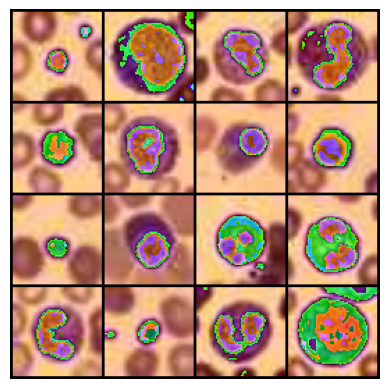

In [6]:
# Visualization
# Get a few samples
samples = [full_dataset[i][0] for i in range(16)]  # assuming (image, label) tuples

# Make a grid
grid = make_grid(samples, nrow=4)

# Display
plt.imshow(F.to_pil_image(grid))
plt.axis('off')
plt.show()

# Generator Architecture

This `Generator` class implements the DCGAN architecture, which upsamples a latent noise vector (`z`) into a 64×64 RGB image through a series of transposed convolutional layers.

- **Input:** Noise tensor of shape `(batch_size, z_dim, 1, 1)` (default `z_dim=100`)
- **Output:** Image tensor of shape `(batch_size, 3, 64, 64)` with pixel values scaled to `[-1, 1]` due to the final `Tanh` activation
- **Architecture:**
  - **Layer 1:** Projects and reshapes the input from 1×1 → 4×4, output channels: `feature_maps * 8`  
  - **Layer 2:** Upsamples from 4×4 → 8×8, output channels: `feature_maps * 4`  
  - **Layer 3:** Upsamples from 8×8 → 16×16, output channels: `feature_maps * 2`  
  - **Layer 4:** Upsamples from 16×16 → 32×32, output channels: `feature_maps`  
  - **Layer 5 (final):** Upsamples from 32×32 → 64×64, output channels: `img_channels` (default 3)  
- **Activations:**  
  - Uses `ReLU` with in-place operation after every transposed convolution except the final layer  
  - Final layer uses `Tanh` to output pixel values in range `[-1, 1]`  
- **Normalization:** Batch Normalization (`BatchNorm2d`) applied after every transposed convolution except the output layer  
- **Weights Initialization:** Custom initialization with normal distribution (`mean=0, std=0.02`) for Conv layers and BatchNorm layers, applied at model instantiation for stable training

In [7]:
def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_maps=64):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # First layer: project and reshape the input noise vector (z_dim x 1 x 1)
            # into a feature map of size (feature_maps * 8) x 4 x 4
            nn.ConvTranspose2d(z_dim, feature_maps * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 8),  # Normalize feature maps for stable training
            nn.ReLU(True),  # Use ReLU activation for non-linearity

            # Second layer: upsample from 4x4 → 8x8
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            # Third layer: upsample from 8x8 → 16x16
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            # Fourth layer: upsample from 16x16 → 32x32
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            # Fifth (final) layer: upsample from 32x32 → 64x64 and reduce to the number of image channels
            nn.ConvTranspose2d(feature_maps, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # Output pixel values in range [-1, 1] using Tanh activation
        )
        self.initialize_weights()

    def initialize_weights(self):
        self.model.apply(weights_init_dcgan)

    def forward(self, input):
        x = self.model(input)
        return x

# Discriminator Architecture

This `Discriminator` class implements a DCGAN-style convolutional neural network that progressively downsamples a 64×64 RGB image into a single scalar output indicating the likelihood of the image being real or fake.

- **Input:** Image tensor of shape `(batch_size, 3, 64, 64)` (3 color channels)
- **Output:** Single scalar per image representing real/fake logits (no sigmoid applied here)
- **Architecture:**  
  - **Conv Layer 1:** 64×64 → 32×32, channels: 3 → `feature_maps` (default 64)  
  - **Conv Layer 2:** 32×32 → 16×16, channels: `feature_maps` → `feature_maps * 2`  
  - **Conv Layer 3:** 16×16 → 8×8, channels: `feature_maps * 2` → `feature_maps * 4`  
  - **Conv Layer 4:** 8×8 → 4×4, channels: `feature_maps * 4` → `feature_maps * 8`  
  - **Conv Layer 5 (final):** 4×4 → 1×1, channels: `feature_maps * 8` → 1 (output logits)  
- **Activations:** LeakyReLU with negative slope 0.2 after every convolution except the last  
- **Normalization:** Uses **Spectral Normalization** on all convolutional layers for training stability (instead of BatchNorm)  
- **Output Shape:** Flattened to `(batch_size,)` for binary classification  
- **Note:**  
  - The final layer does not include a `Sigmoid` because the training uses `BCEWithLogitsLoss`, which combines sigmoid activation internally for better numerical stability.  
  - Spectral Normalization controls the Lipschitz constant of each layer, helping stabilize GAN training and reduce mode collapse.



In [8]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_maps=64):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # First layer: 64x64 → 32x32
            utils.spectral_norm(nn.Conv2d(img_channels, feature_maps, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Second layer: 32x32 → 16x16
            utils.spectral_norm(nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Third layer: 16x16 → 8x8
            utils.spectral_norm(nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Fourth layer: 8x8 → 4x4
            utils.spectral_norm(nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            # Final layer: 4x4 → 1x1
            # Produces a single value that represents the probability of the image being real or fake
            utils.spectral_norm(nn.Conv2d(feature_maps * 8, 1, 4, 1, 0, bias=False)),

            # nn.Sigmoid() - it's commented out because we're using BCEWithLogitsLoss. This loss function includes the sigmoid internally for better numerical stability
        )

    def forward(self, input):
        return self.model(input).view(-1, 1).squeeze(1)  # Flatten the output to shape (batch_size,)

### FID Evaluation Function (`compute_fid_safe`)

This function calculates the **Fréchet Inception Distance (FID)** between real and generated images to evaluate the quality of a GAN generator.

- **Input Parameters**:
  - `model`: Generator model used to create fake images
  - `num_samples`: Total number of real and fake images to compare (default: 10,000)
  - `batch_size`: Batch size for both real and fake images
  - `z_dim`: Dimensionality of the generator’s latent vector

- **Real Image Processing**:
  - Images are scaled from `[-1, 1]` to `[0, 1]` before FID update
  - Stops after processing the desired number of samples

- **Fake Image Generation**:
  - Generates images from random noise (`z`)
  - Applies same scaling as real images
  - Updates FID statistics with fake samples

- **Memory Management**:
  - Uses `torch.no_grad()` to disable gradients
  - Cleans up memory with `del` and `torch.cuda.empty_cache()` to avoid GPU overflow

- **Returns**: Final FID score as a float


In [9]:
def compute_fid_safe(model, num_samples=10000, batch_size=256, z_dim=100):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)  # Initialize the FID metric from torchmetrics
    model.eval()  # Set the generator model to evaluation mode

    # -------------------- Process Real Images --------------------
    real_processed = 0  # Counter to track how many real images have been processed

    with torch.no_grad():  # Disable gradient computation for efficiency
        for x, _ in DataLoader(full_dataset, batch_size=batch_size):
            x = x.to(device)

            # Rescale pixel values from [-1, 1] to [0, 1], which is expected by InceptionV3
            x_scaled = (x + 1) / 2
            x_scaled = x_scaled.clamp(0, 1)

            fid.update(x_scaled, real=True)  # Update the FID with real images
            real_processed += x.shape[0]  # Increment the counter

            if real_processed >= num_samples:
                break  # Stop if we have enough real images

    # -------------------- Process Generated (Fake) Images --------------------
    for i in range(0, num_samples, batch_size):
        with torch.no_grad():
            z = torch.randn(min(batch_size, num_samples-i), z_dim, 1, 1, device=device)  # Generate a batch of random noise vectors
            fake_images = model(z)  # Generate fake images using the generator

            # Rescale generated images from [-1, 1] to [0, 1]
            fake_scaled = (fake_images + 1) / 2
            fake_scaled = fake_scaled.clamp(0, 1)

            fid.update(fake_scaled, real=False)  # Update the FID metric with generated images

        # Clean up memory after each batch to avoid CUDA out-of-memory errors
        del z, fake_images, fake_scaled
        torch.cuda.empty_cache()

    return fid.compute().item()  # Compute and return the final FID score as a Python float

# DCGAN Training Loop (`train_dcgan`)

This function trains a Deep Convolutional GAN by alternating updates between the Generator and Discriminator networks, tracks their losses, evaluates image quality with FID, and manages saving of model checkpoints.

### Setup
- Uses `BCEWithLogitsLoss` to combine a sigmoid layer and binary cross-entropy in a numerically stable way for real-vs-fake classification.
- Optimizers: Adam with learning rates of `1e-4` for the Discriminator and the Generator, with betas set to `(0.0, 0.9)` for stable training.
- Models and tensors are moved to the specified device (GPU if available).
- Label smoothing applied to real labels (random values in [0.9, 1.0]) and occasional label flipping (5% chance) to regularize discriminator training.
- Accepts a PyTorch DataLoader as input and uses a latent noise dimension `z_dim` (default 100).

### Training Loop (per epoch)
1. **Training the Discriminator**
   - Receives batches of real images labeled close to 1 and fake images (produced by the Generator) labeled 0.
   - Calculates separate loss components for real and fake images and sums them.
   - Updates Discriminator parameters to improve its classification accuracy.
   
2. **Training the Generator**
   - Generates new fake images from random noise.
   - Attempts to fool the Discriminator into classifying these fakes as real.
   - Calculates loss accordingly and updates Generator parameters.
   - Includes an additional Generator update if the Discriminator’s loss drops below a small threshold (0.01) to prevent the Discriminator from overpowering the Generator.

3. **Logging**
   - Records average Discriminator and Generator losses per epoch to TensorBoard.
   - Tracks discriminator confidence scores on real images (`D(x)`) and fake images both before and after Generator updates (`D(G(z))`).

### Evaluation
- Every 5 epochs (and at the final epoch), computes the **Fréchet Inception Distance (FID)** on 5,000 generated samples to assess the quality and diversity of generated images.
- FID measures similarity between generated and real images in feature space; lower values indicate better quality.
- Logs FID scores to TensorBoard.
- Saves the model with the best (lowest) FID score, including weights and optimizer states.

### Checkpoints
- Saves a checkpoint every 10 epochs containing model weights, optimizer states, losses, and the last computed FID.
- Checkpoints facilitate resuming training or debugging.

### Image Logging
- Generated images are rescaled from `[-1, 1]` to `[0, 1]` before being logged to TensorBoard for visualization.

### Return Values
- Lists of average Discriminator and Generator losses per epoch.
- List of FID scores recorded at evaluation intervals.
- The best FID score and the epoch at which it was achieved.

In [ ]:
# Instantiate the generator and discriminator with a feature map size of 128
generator = Generator(z_dim=100, feature_maps=128).to(device)
discriminator = Discriminator(feature_maps=128).to(device)

#criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy with Logits for better numerical stability (combines sigmoid + BCE)

# Define optimizers for both generator and discriminator using Adam
optimizer_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.0, 0.9))

# Main training loop for DCGAN
def train_dcgan(dataloader, z_dim=100, epochs=100, m_dir=best_models, c_dir=checkpoints):
    losses_D = []  # List to store discriminator losses per epoch
    losses_G = []  # List to store generator losses per epoch
    fid_scores = []  # List to track FID score every 5 epochs
    best_fid = float('inf')  # Initialize best FID score with infinity
    best_epoch = 0  # Track the epoch with the best FID score

    for epoch in range(epochs):
        total_loss_D = 0  # Accumulate discriminator loss for this epoch
        total_loss_G = 0  # Accumulate generator loss for this epoch

        # Iterate over the dataset
        for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            batch_size = real.size(0)

            # Create real and fake labels for discriminator training
            # Use label smoothing for real labels: random values between 0.9 and 1.0 instead of fixed 1.0
            real_labels = torch.empty(batch_size, device=device).uniform_(0.9, 1.0)
            fake_labels = torch.zeros(batch_size, device=device)

            # Occasionally flip labels (5% chance) to regularize training and avoid discriminator overpowering
            if torch.rand(1).item() < 0.05:
                real_labels, fake_labels = fake_labels.clone(), real_labels.clone()

            # === Train the Discriminator ===
            # Generate fake images from random noise z
            z = torch.randn(batch_size, z_dim, 1, 1, device=device)
            fake_images = generator(z)

            # Get discriminator predictions for real and fake images
            real_pred = discriminator(real)
            fake_pred = discriminator(fake_images.detach())  # Detach so G isn't updated here

            # Compute loss for real and fake images
            loss_D_real = criterion(real_pred, real_labels)
            loss_D_fake = criterion(fake_pred, fake_labels)
            loss_D = loss_D_real + loss_D_fake

            total_loss_D += loss_D.item()

            # Update discriminator weights
            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # Track discriminator confidence
            D_x = real_pred.mean().item()         # Confidence for real images
            D_G_z1 = fake_pred.mean().item()      # Confidence for fake images (before generator update)

            # === Train the Generator ===
            # Generate new fake images
            z = torch.randn(batch_size, z_dim, 1, 1, device=device)
            fake_images = generator(z)
            pred = discriminator(fake_images)

            # Compute loss (Generator wants the discriminator to classify fake as real)
            loss_G = criterion(pred, real_labels)

            total_loss_G += loss_G.item()

            # Update generator weights
            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

            # Confidence after generator update
            D_G_z2 = pred.mean().item()

            # === Extra Generator Training if Discriminator Loss is too low ===
            # If discriminator is too confident (loss below threshold), train generator again to rebalance
            if loss_D.item() < 0.01:
                z = torch.randn(batch_size, z_dim, 1, 1, device=device)
                fake_images = generator(z)
                pred = discriminator(fake_images)
                loss_G_extra = criterion(pred, real_labels)

                optimizer_G.zero_grad()
                loss_G_extra.backward()
                optimizer_G.step()

        # Average losses per epoch
        avg_loss_D = total_loss_D / len(dataloader)
        avg_loss_G = total_loss_G / len(dataloader)

        writer.add_scalar('Loss/discriminator', avg_loss_D, epoch)
        writer.add_scalar('Loss/generator', avg_loss_G, epoch)

        losses_D.append(avg_loss_D)
        losses_G.append(avg_loss_G)

        # === FID Evaluation every 5 epochs ===
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            current_fid = compute_fid_safe(generator, num_samples=5000, z_dim=z_dim)  # Smaller sample for frequent checks
            fid_scores.append(current_fid)
            writer.add_scalar('FID/validation', current_fid, epoch)

            print(f"Epoch {epoch+1}/{epochs}: \n\tLoss Discriminator: {avg_loss_D:.4f} - Loss Generator: {avg_loss_G:.4f} - FID: {current_fid:.2f}")

            # Save best model (lowest FID so far)
            if current_fid < best_fid:
                best_fid = current_fid
                best_epoch = epoch + 1

                torch.save({
                    'epoch': epoch + 1,
                    'generator_state_dict': generator.state_dict(),
                    'discriminator_state_dict': discriminator.state_dict(),
                    'optimizer_state_dict_D': optimizer_D.state_dict(),
                    'optimizer_state_dict_G': optimizer_G.state_dict(),
                    'loss_D': avg_loss_D,
                    'loss_G': avg_loss_G,
                    'fid': best_fid,
                }, os.path.join(m_dir, f'best_dcgan_epoch{epoch+1}_fid{best_fid:.2f}.pth'))

                # Save sample generated images for visual tracking
                with torch.no_grad():
                    z = torch.randn(batch_size, z_dim, 1, 1, device=device)
                    sample_images = generator(z)
                    sample_images = (sample_images + 1) / 2  # Rescale to [0,1]
                    grid = make_grid(sample_images, nrow=8, padding=2)
                    writer.add_image('Generated Images', grid, epoch)

        # Save model checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'generator_state_dict': generator.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'optimizer_state_dict_D': optimizer_D.state_dict(),
                'optimizer_state_dict_G': optimizer_G.state_dict(),
                'loss_D': avg_loss_D,
                'loss_G': avg_loss_G,
                'fid': current_fid if 'current_fid' in locals() else None,
            }, os.path.join(c_dir, f'checkpoint_epoch{epoch+1}.pth'))

    return losses_D, losses_G, fid_scores, best_fid, best_epoch

# Start training for 150 epochs and collect results
losses_D, losses_G, fid_scores, best_fid, best_epoch = train_dcgan(dataloader, epochs=150)

Epoch 5/150: 100%|██████████| 67/67 [00:09<00:00,  6.74it/s]
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 203MB/s]


Epoch 5/150: 
	Loss Discriminator: 1.2896 - Loss Generator: 0.7575 - FID: 418.94


Epoch 10/150: 100%|██████████| 67/67 [00:09<00:00,  6.81it/s]


Epoch 10/150: 
	Loss Discriminator: 1.3134 - Loss Generator: 0.7026 - FID: 390.56


Epoch 15/150: 100%|██████████| 67/67 [00:09<00:00,  6.76it/s]


...

Epoch 140/150: 
	Loss Discriminator: 1.3329 - Loss Generator: 0.7165 - FID: 55.65


Epoch 145/150: 100%|██████████| 67/67 [00:10<00:00,  6.67it/s]


Epoch 145/150: 
	Loss Discriminator: 1.3425 - Loss Generator: 0.7123 - FID: 52.75


Epoch 150/150: 100%|██████████| 67/67 [00:10<00:00,  6.64it/s]


Epoch 150/150: 
	Loss Discriminator: 1.3209 - Loss Generator: 0.7288 - FID: 42.30


## Model Evaluation and Image Generation

- **Load Best Model**: Loads the saved Generator checkpoint with the best FID score and switches it to evaluation mode.

- **Generate 10,000 Images**:
  - Images are generated in batches to manage memory.
  - Each image is scaled from `[-1, 1]` to `[0, 1]` and saved individually as PNG files.

- **Final FID Evaluation**:
  - Runs FID computation 5 times with different random seeds for robustness.
  - Prints individual FID scores per run.
  - Calculates and displays the average and standard deviation of the FID scores.


In [11]:
# Load the best saved generator model based on FID score
best_model_path = os.path.join(best_models, f'best_dcgan_epoch{best_epoch}_fid{best_fid:.2f}.pth')
checkpoint = torch.load(best_model_path)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()  # Set generator to evaluation mode

# === Final Evaluation and Image Generation ===
print("\nGenerating 10,000 images for final evaluation...")
final_images_dir = os.path.join(images_dir, 'final_10k')
os.makedirs(final_images_dir, exist_ok=True)  # Create the output directory if it doesn't exist

# Generate images in batches to avoid memory issues
with torch.no_grad():  # Disable gradient tracking for faster inference and lower memory use
    for i in tqdm(range(0, 10000, batch_size)):
        z = torch.randn(min(batch_size, 10000-i), 100, 1, 1, device=device)  # Sample latent vectors

        images = generator(z)
        images = (images + 1) / 2  # Rescale pixel values from [-1, 1] to [0, 1]

        # Save each image to disk
        for j in range(images.shape[0]):
            save_image(images[j], os.path.join(final_images_dir, f"img_{i+j:05d}.png"))

# === Final FID Evaluation ===
print("\nRunning final FID evaluation (5 runs with 10k samples)...")
final_fid_scores = []  # Store FID scores for each run

for run in range(5):
    print(f"\nRun {run+1}/5")

    # Set seeds for reproducibility
    torch.manual_seed(run)
    np.random.seed(run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run)

    # Compute FID score
    try:
        fid = compute_fid_safe(generator, num_samples=10000, batch_size=batch_size)
        final_fid_scores.append(fid)
        print(f"FID = {fid:.2f}")
        torch.cuda.empty_cache()  # Free up GPU memory

    except Exception as e:
        print(f"Error in run {run+1}: {str(e)}")
        continue

# Report final results
if final_fid_scores:
    avg_fid = np.mean(final_fid_scores)
    std_fid = np.std(final_fid_scores)
    print(f"\nFinal FID: {avg_fid:.2f} ± {std_fid:.2f}")  # Mean ± standard deviation

else:
    print("Failed to compute FID in all runs.")
    avg_fid = float('inf')
    std_fid = 0


Generating 10,000 images for final evaluation...


100%|██████████| 40/40 [00:54<00:00,  1.37s/it]



Running final FID evaluation (5 runs with 10k samples)...

Run 1/5
FID = 41.01

Run 2/5
FID = 41.27

Run 3/5
FID = 41.36

Run 4/5
FID = 40.85

Run 5/5
FID = 41.35

Final FID: 41.17 ± 0.20


## Training Results Visualization

- **Loss Curves**:  
  Plots discriminator and generator training losses over all epochs to track convergence and stability.

- **FID Curve**:  
  Shows FID score progression during training at every 5 epochs, indicating the improvement of generated image quality.

- **Sample Images Grid**:  
  Displays a 3x3 grid of randomly selected generated images from the final 10,000 images, providing a visual example of the generator’s output.

- **Output**:  
  The complete figure is saved as `training_results.png` for easy reference.


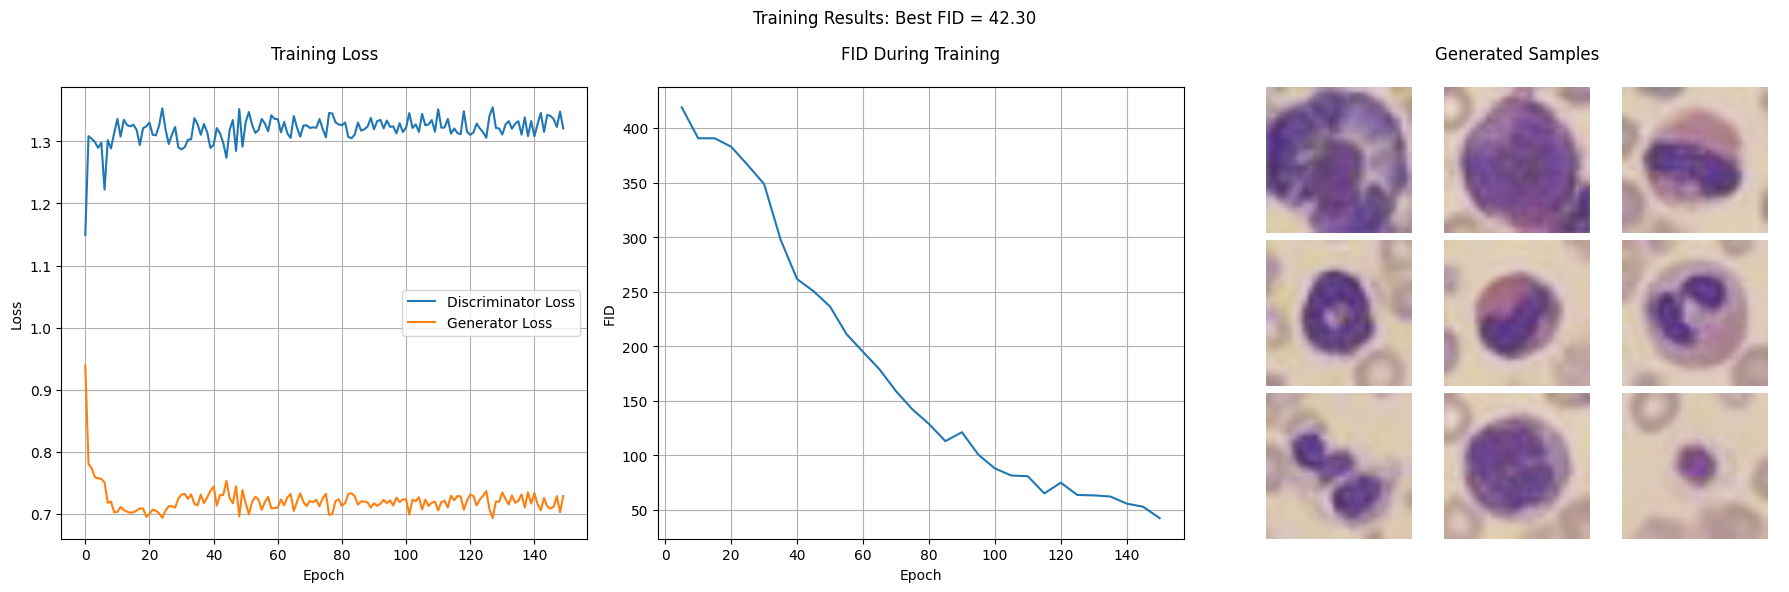

In [12]:
# Create a wide figure with 3 subplots side-by-side
plt.figure(figsize=(18, 6))

gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 1])  # Define a GridSpec layout with 3 equally sized columns

# === Subplot 1: Plot Generator and Discriminator Losses ===
ax1 = plt.subplot(gs[0])
ax1.plot(losses_D, label='Discriminator Loss')
ax1.plot(losses_G, label='Generator Loss')
ax1.set_title('Training Loss', pad=20)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# === Subplot 2: Plot FID Score Curve ===
if fid_scores:
    ax2 = plt.subplot(gs[1])
    ax2.plot(range(5, len(fid_scores)*5+1, 5), fid_scores)  # Plot FID every 5 epochs
    ax2.set_title('FID During Training', pad=20)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('FID')
    ax2.grid(True)

# === Subplot 3: Show a 3x3 Grid of Sample Images ===
ax3 = plt.subplot(gs[2])
ax3.set_title('Generated Samples', pad=20)
ax3.axis('off')  # Hide the axis frame

# Define a 3x3 subgrid inside the third subplot for 9 images
sub_gs = gs[2].subgridspec(3, 3, wspace=0.05, hspace=0.05)

# Randomly select 9 image files from the final image directory
sample_files = np.random.choice(os.listdir(final_images_dir), 9, replace=False)

# Loop through each position in the 3x3 grid
for i in range(9):
    row = i // 3
    col = i % 3
    ax_img = plt.subplot(sub_gs[row, col])
    img = plt.imread(os.path.join(final_images_dir, sample_files[i]))  # Load image
    ax_img.imshow(img)  # Show image in subplot
    ax_img.axis('off')

plt.suptitle(f'Training Results: Best FID = {best_fid:.2f}')
plt.tight_layout()

# Save the entire figure to disk
plot_path = os.path.join(project_path, 'training_results.png')
plt.savefig(plot_path)
plt.show()

## Save Training Results and Summary

Saves the final training metrics and model parameters after the DCGAN training is complete.

- Saves detailed results including losses, FID scores, and best epoch to a JSON file for future reference.
- Writes a human-readable summary text file with key results and training parameters.
- Records the number of saved model files, generated images, training plots, and TensorBoard logs.
- Closes the TensorBoard writer to finalize logging.
- Prints a summary of the training completion and the best final FID scores.


In [13]:
# === Prepare Final Results Dictionary for Saving ===
results = {
    'best_fid': float(best_fid),
    'best_epoch': int(best_epoch),
    'final_fid': float(avg_fid),
    'final_fid_std': float(std_fid),
    'losses_D': [float(x) for x in losses_D],
    'losses_G': [float(x) for x in losses_G],
    'fid_scores': [float(x) for x in fid_scores],
    'final_fid_scores': [float(x) for x in final_fid_scores],
    'model_params': {
        'z_dim': 100,
        'lr': 1e-4,
        'epochs': 150,
    }
}

# === Save All Results as a JSON File ===
with open(os.path.join(project_path, 'training_results.json'), 'w') as f:
    json.dump(results, f, indent=4)  # Indented for readability

# === Save a Readable Summary to a Text File ===
with open(os.path.join(project_path, 'results_summary.txt'), 'w') as f:
    f.write(f"=== DCGAN Training Results ===\n\n")
    f.write(f"Best FID: {best_fid:.2f} at epoch {best_epoch}\n")
    f.write(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}\n\n")

    f.write(f"Training Parameters:\n")
    f.write(f"- Z dimension: 100\n")
    f.write(f"- Learning rate: 1e-4\n")
    f.write(f"- Epochs: 150\n")
    f.write(f"- Batch size: {batch_size}\n\n")

    f.write(f"Files saved:\n")
    f.write(f"- Models: {len(os.listdir(best_models))} files in {best_models}\n")
    f.write(f"- Generated images: {len(os.listdir(final_images_dir))} files in {final_images_dir}\n")
    f.write(f"- Training plots: {plot_path}\n")
    f.write(f"- TensorBoard logs: {logs_dir}\n")

# Close TensorBoard writer
writer.close()

print(f"\nTraining complete! All files saved to: {project_path}")
print(f"Best FID achieved: {best_fid:.2f} at epoch {best_epoch}")
print(f"Final FID (10k samples): {avg_fid:.2f} ± {std_fid:.2f}")


Training complete! All files saved to: /content/drive/MyDrive/ColabNotebooks/TP2
Best FID achieved: 42.30 at epoch 150
Final FID (10k samples): 41.17 ± 0.20


# Hyperparameter Grid Search for DCGAN

Performs a grid search over multiple hyperparameter combinations to find the best configuration for training a DCGAN model on the full dataset.

## Parameters Explored:
- **Latent vector dimension (`z_dim`)**: 100, 128  
- **Number of feature maps (`feature_maps`)**: 64, 128  
- **Discriminator learning rate (`lr_D`)**: 5e-5, 1e-4  
- **Generator learning rate (`lr_G`)**: 5e-5, 1e-4  
- **Batch size (`batch_size`)**: 128, 256  

## Training Setup:
- For each hyperparameter combination, the model is trained for **25 epochs** using the full dataset.
- Both **discriminator and generator losses** are tracked over time.
- **Label smoothing** and **label flipping** are used to stabilize training.
- An extra generator step is added when discriminator loss drops too low (to avoid overpowering the generator).

## Evaluation:
- After training, **FID** is computed on **5,000 generated samples** to evaluate generation quality.
- FID scores and training histories are saved for each configuration.
- The **best model** (lowest FID) is saved along with its parameters and optimizer states.

## Output:
- All results are saved to `grid_search_results.json` for further analysis.
- The **best configuration** and the **top 5 combinations by FID** are printed at the end of the search.

In [14]:
# === Define Grid of Hyperparameters to Search Over ===
param_grid = {
    'z_dim': [100, 128],  # Latent space dimensions
    'feature_maps': [64, 128],  # Number of feature maps in generator/discriminator
    'lr_D': [5e-5, 1e-4],  # Learning rates of the discriminator
    'lr_G': [5e-5, 1e-4],  # Learning rates of the generator
    'batch_size': [128, 256]  # Batch sizes
}

# Generate all combinations of hyperparameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
print(f"Total combinations: {len(all_params)}")

# Initialize tracking variables for best configuration
grid_best_fid = float('inf')
grid_best_model = None
grid_best_params = None
results = []  # Store history and FID for each config

# === Loop Over Each Hyperparameter Combination ===
for i, params in enumerate(all_params):
    print(f"\n=== Training combination {i+1}/{len(all_params)} ===")
    print("Parameters:", params)

    # Create dataloader with specified batch size
    dataloader = DataLoader(full_dataset, batch_size=params['batch_size'], shuffle=True)

    # Initialize generator and discriminator with current parameters
    generator = Generator(z_dim=params['z_dim'], feature_maps=params['feature_maps']).to(device)
    discriminator = Discriminator(feature_maps=params['feature_maps']).to(device)

    # Set loss function and optimizers
    criterion = nn.BCEWithLogitsLoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=params['lr_G'], betas=(0.0, 0.9))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=params['lr_D'], betas=(0.0, 0.9))

    # Track training history
    history = {
        'losses_D': [],
        'losses_G': [],
        'fid_scores': [],
    }

    num_epochs = 25
    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        total_loss_D = 0
        total_loss_G = 0

        # === Training Loop for One Epoch ===
        for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            real = real.to(device)
            batch_size = real.size(0)

            real_labels = torch.empty(batch_size, device=device).uniform_(0.9, 1.0)
            fake_labels = torch.zeros(batch_size, device=device)

            if torch.rand(1).item() < 0.05:
                real_labels, fake_labels = fake_labels.clone(), real_labels.clone()

            # --- Train Discriminator ---
            z = torch.randn(batch_size, params['z_dim'], 1, 1, device=device)
            fake_images = generator(z)

            real_pred = discriminator(real)
            fake_pred = discriminator(fake_images.detach())

            loss_D_real = criterion(real_pred, real_labels)
            loss_D_fake = criterion(fake_pred, fake_labels)
            loss_D = loss_D_real + loss_D_fake

            total_loss_D += loss_D.item()

            optimizer_D.zero_grad()
            loss_D.backward()
            optimizer_D.step()

            # --- Train Generator ---
            z = torch.randn(batch_size, params['z_dim'], 1, 1, device=device)
            fake_images = generator(z)
            pred = discriminator(fake_images)

            loss_G = criterion(pred, real_labels)  # Generator wants to fool discriminator
            total_loss_G += loss_G.item()

            optimizer_G.zero_grad()
            loss_G.backward()
            optimizer_G.step()

            # If discriminator is too confident (loss below threshold), train generator again to rebalance
            if loss_D.item() < 0.01:
                z = torch.randn(batch_size, params['z_dim'], 1, 1, device=device)
                fake_images = generator(z)
                pred = discriminator(fake_images)
                loss_G_extra = criterion(pred, real_labels)

                optimizer_G.zero_grad()
                loss_G_extra.backward()
                optimizer_G.step()

        # Record average losses
        avg_loss_D = total_loss_D / len(dataloader)
        avg_loss_G = total_loss_G / len(dataloader)
        history['losses_D'].append(avg_loss_D)
        history['losses_G'].append(avg_loss_G)

        print(f"Epoch {epoch+1}/{num_epochs}: \n\tLoss Discriminator: {avg_loss_D:.4f} - Loss Generator: {avg_loss_G:.4f}")

    # === Compute FID for This Model ===
    fid = compute_fid_safe(generator, num_samples=5000, z_dim=params['z_dim'])
    history['fid_scores'].append(fid)
    print(f"FID: {fid:.2f}")

    # Store results
    results.append({
        'params': params,
        'history': history,
        'fid': fid,
    })

    # Save best model so far
    if fid < grid_best_fid:
        grid_best_fid = fid
        grid_best_model = generator
        grid_best_params = params

        torch.save({
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'params': params,
            'optimizer_state_dict_D': optimizer_D.state_dict(),
            'optimizer_state_dict_G': optimizer_G.state_dict(),
            'history': history,
            'fid': fid,
        }, os.path.join(best_grid_models, f'best_dcgan_grid_search.pth'))

# === Final Reporting ===
print("\n=== Grid Search Complete ===")
print(f"Best FID: {grid_best_fid:.2f}")
print("Best parameters:")
print(grid_best_params)

# Save all results as JSON
with open(os.path.join(project_path, 'grid_search_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

# Print top 5 configurations by FID
sorted_results = sorted(results, key=lambda x: x['fid'])
print("\nTop 5 configurations:")
for i, res in enumerate(sorted_results[:5]):
    print(f"{i+1}. FID: {res['fid']:.2f} - Params: {res['params']}")

Total combinations: 32

=== Training combination 1/32 ===
Parameters: {'z_dim': 100, 'feature_maps': 64, 'lr_D': 5e-05, 'lr_G': 5e-05, 'batch_size': 128}


Epoch 1/25: 100%|██████████| 134/134 [00:09<00:00, 14.31it/s]


Epoch 1/25: 
	Loss Discriminator: 1.1488 - Loss Generator: 0.7213


Epoch 2/25: 100%|██████████| 134/134 [00:09<00:00, 14.31it/s]


Epoch 2/25: 
	Loss Discriminator: 1.3129 - Loss Generator: 0.6356


...

Epoch 23/25: 
	Loss Discriminator: 1.2791 - Loss Generator: 0.8594


Epoch 24/25: 100%|██████████| 67/67 [00:09<00:00,  6.83it/s]


Epoch 24/25: 
	Loss Discriminator: 1.2597 - Loss Generator: 0.8895


Epoch 25/25: 100%|██████████| 67/67 [00:09<00:00,  6.82it/s]


Epoch 25/25: 
	Loss Discriminator: 1.2613 - Loss Generator: 0.8913
FID: 354.80

=== Grid Search Complete ===
Best FID: 269.60
Best parameters:
{'z_dim': 100, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128}

Top 5 configurations:
1. FID: 269.60 - Params: {'z_dim': 100, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128}
2. FID: 282.89 - Params: {'z_dim': 128, 'feature_maps': 128, 'lr_D': 5e-05, 'lr_G': 0.0001, 'batch_size': 128}
3. FID: 286.33 - Params: {'z_dim': 128, 'feature_maps': 128, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128}
4. FID: 290.63 - Params: {'z_dim': 100, 'feature_maps': 128, 'lr_D': 5e-05, 'lr_G': 0.0001, 'batch_size': 128}
5. FID: 318.65 - Params: {'z_dim': 128, 'feature_maps': 64, 'lr_D': 0.0001, 'lr_G': 0.0001, 'batch_size': 128}


# Load Best Grid Search Model and Continue Training

Loads the best model found during the hyperparameter grid search and prepares it for further training:

- Loads checkpoint containing the best generator and discriminator state dictionaries, best hyperparameters, and best FID score.
- Recreates the data loader with the best batch size.
- Instantiates the generator and discriminator models with the best found parameters.
- Sets up the loss function (BCEWithLogitsLoss) and Adam optimizers with the best learning rate.
- Continues training the DCGAN for 150 epochs starting from the saved checkpoint to further improve performance.
- Saves intermediate checkpoints and logs in the specified directories for monitoring.

In [16]:
# === Load Best Model Checkpoint from Grid Search ===
checkpoint = torch.load('models/best_grid_models/best_dcgan_grid_search.pth', weights_only=False)

# Extract generator and discriminator weights, best params, and FID score
best_generator = checkpoint['generator_state_dict']
best_discriminator = checkpoint['discriminator_state_dict']
best_params = checkpoint['params']
best_fid = checkpoint['fid']

# === Prepare DataLoader with Best Batch Size ===
dataloader = DataLoader(full_dataset, batch_size=best_params['batch_size'], shuffle=True)

# === Re-initialize Models Using Best Parameters ===
generator = Generator(z_dim=best_params['z_dim'], feature_maps=best_params['feature_maps']).to(device)
discriminator = Discriminator(feature_maps=best_params['feature_maps']).to(device)

# === Define Loss Function and Optimizers Using Best Learning Rate ===
criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(generator.parameters(), lr=best_params['lr_G'], betas=(0.0, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=best_params['lr_D'], betas=(0.0, 0.9))

# === Retrain the DCGAN Using the Best Found Configuration ===
# Run for 150 epochs and save model checkpoints to specified directories
grid_losses_D, grid_losses_G, grid_fid_scores, grid_best_fid, grid_best_epoch = train_dcgan(dataloader, z_dim=best_params['z_dim'], epochs=150, m_dir=best_grid_models, c_dir=grid_checkpoints)

Epoch 5/150: 100%|██████████| 134/134 [00:10<00:00, 12.24it/s]


Epoch 5/150: 
	Loss Discriminator: 1.2108 - Loss Generator: 0.9654 - FID: 405.38


Epoch 10/150: 100%|██████████| 134/134 [00:11<00:00, 12.18it/s]


Epoch 10/150: 
	Loss Discriminator: 1.1270 - Loss Generator: 1.1176 - FID: 378.79


Epoch 15/150: 100%|██████████| 134/134 [00:11<00:00, 12.16it/s]


...

Epoch 140/150: 
	Loss Discriminator: 1.3421 - Loss Generator: 0.7090 - FID: 55.99


Epoch 145/150: 100%|██████████| 134/134 [00:10<00:00, 12.35it/s]


Epoch 145/150: 
	Loss Discriminator: 1.3355 - Loss Generator: 0.7123 - FID: 40.78


Epoch 150/150: 100%|██████████| 134/134 [00:10<00:00, 12.31it/s]


Epoch 150/150: 
	Loss Discriminator: 1.3404 - Loss Generator: 0.7118 - FID: 39.13


## Load Best Grid Search Model Checkpoint and Perform Final Evaluation

- Loads the best saved model checkpoint based on the epoch and FID score.
- Loads the generator weights and sets it to evaluation mode.
- Generates 10,000 images in batches, saving them to a designated directory.
- Runs the final FID evaluation 5 times with 10,000 generated samples each run to get a robust estimate.
- Sets random seeds before each run for reproducibility.
- Calculates and prints the mean and standard deviation of the FID scores across the runs.


In [17]:
# Construct the path to the best model checkpoint saved during grid search
grid_best_model_path = os.path.join(best_grid_models, f'best_dcgan_epoch{grid_best_epoch}_fid{grid_best_fid:.2f}.pth')
checkpoint = torch.load(grid_best_model_path)  # Load the checkpoint containing the best model weights and other info
generator.load_state_dict(checkpoint['generator_state_dict'])  # Load the generator weights from the checkpoint
generator.eval()  # Set generator to evaluation mode

# Final Evaluation and Image Generation
print("\nGenerating 10,000 images for final evaluation...")
grid_final_images_dir = os.path.join(images_dir, 'final_10k_grid')
os.makedirs(grid_final_images_dir, exist_ok=True)

# Generate in batches to save memory
with torch.no_grad():
    for i in tqdm(range(0, 10000, batch_size)):
        z = torch.randn(min(batch_size, 10000-i), 100, 1, 1, device=device)
        images = generator(z)
        images = (images + 1) / 2  # Scale images from [-1, 1] range to [0, 1] for saving

        for j in range(images.shape[0]):
            save_image(images[j], os.path.join(grid_final_images_dir, f"img_{i+j:05d}.png"))

# Final FID evaluation (5 runs)
print("\nRunning final FID evaluation (5 runs with 10k samples)...")
grid_final_fid_scores = []  # Initialize list to hold FID scores from multiple runs

# Run FID evaluation 5 times with different random seeds for robustness
for run in range(5):
    print(f"\nRun {run+1}/5")

    torch.manual_seed(run)
    np.random.seed(run)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run)

    try:
        # Compute FID score for the generator using 10,000 generated samples
        fid = compute_fid_safe(generator, num_samples=10000, batch_size=batch_size)
        grid_final_fid_scores.append(fid)  # Store the computed FID score
        print(f"FID = {fid:.2f}")
        torch.cuda.empty_cache()  # Clear CUDA cache to free memory between runs

    except Exception as e:
        print(f"Error in run {run+1}: {str(e)}")
        continue

# After all runs, compute and print mean and standard deviation of FID scores
if grid_final_fid_scores:
    grid_avg_fid = np.mean(grid_final_fid_scores)
    grid_std_fid = np.std(grid_final_fid_scores)
    print(f"\nFinal FID: {grid_avg_fid:.2f} ± {grid_std_fid:.2f}")

else:
    print("Failed to compute FID in all runs.")
    grid_avg_fid = float('inf')
    grid_std_fid = 0


Generating 10,000 images for final evaluation...


100%|██████████| 52/52 [00:57<00:00,  1.10s/it]



Running final FID evaluation (5 runs with 10k samples)...

Run 1/5
FID = 38.37

Run 2/5
FID = 38.29

Run 3/5
FID = 37.63

Run 4/5
FID = 37.04

Run 5/5
FID = 37.82

Final FID: 37.83 ± 0.49


## Visualize Grid Search Training Results

Generates a visualization of the training process and final outputs:

1. **Training Loss Curves:**  
   Plots discriminator and generator losses across epochs to monitor training stability and convergence.

2. **FID Score Curve:**  
   Shows the FID metric progression during training, evaluated every 5 epochs, to track model quality improvements.

3. **Generated Sample Images:**  
   Displays a 3x3 grid of randomly selected generated images from the final 10,000 samples, providing a qualitative sense of the generator’s performance.

The figure is saved as `grid_training_results.png` inside the project directory.


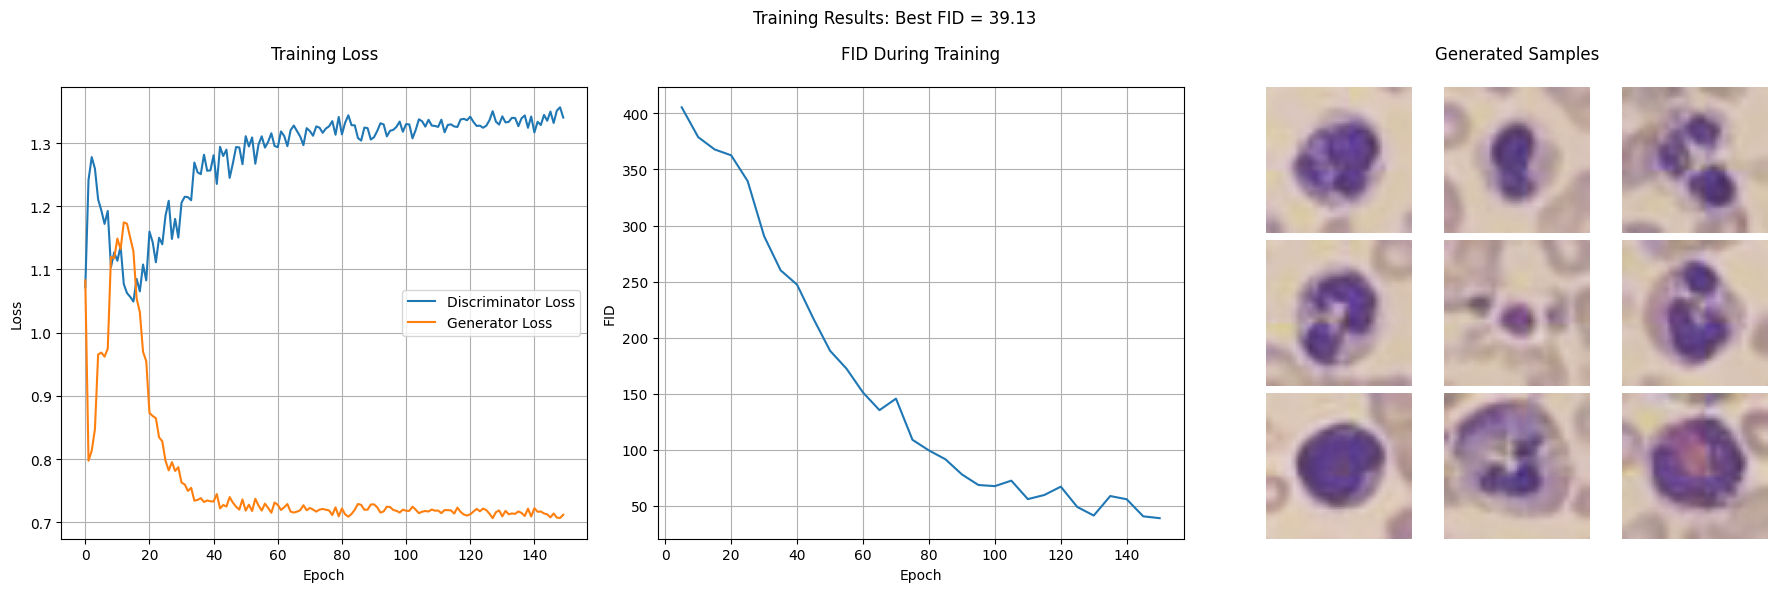

In [18]:
plt.figure(figsize=(18, 6))

# Create a grid layout with 1 row and 3 columns, each subplot equally sized
gs = plt.GridSpec(1, 3, width_ratios=[1, 1, 1])

# Subplot 1: Plot training losses for discriminator and generator
ax1 = plt.subplot(gs[0])
ax1.plot(grid_losses_D, label='Discriminator Loss')
ax1.plot(grid_losses_G, label='Generator Loss')
ax1.set_title('Training Loss', pad=20)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Subplot 2: Plot FID scores recorded during training (every 5 epochs)
if grid_fid_scores:
    ax2 = plt.subplot(gs[1])
    ax2.plot(range(5, len(grid_fid_scores)*5+1, 5), grid_fid_scores)
    ax2.set_title('FID During Training', pad=20)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('FID')
    ax2.grid(True)

# Subplot 3: Display a 3x3 grid of sample generated images
ax3 = plt.subplot(gs[2])
ax3.set_title('Generated Samples', pad=20)
ax3.axis('off')

sub_gs = gs[2].subgridspec(3, 3, wspace=0.05, hspace=0.05)

# Randomly select 9 image filenames from the directory of generated images
grid_sample_files = np.random.choice(os.listdir(grid_final_images_dir), 9, replace=False)

# Loop over the 9 chosen images to load and display each in the subgrid
for i in range(9):
    row = i // 3
    col = i % 3
    ax_img = plt.subplot(sub_gs[row, col])
    img = plt.imread(os.path.join(grid_final_images_dir, grid_sample_files[i]))
    ax_img.imshow(img)
    ax_img.axis('off')

plt.suptitle(f'Training Results: Best FID = {grid_best_fid:.2f}')
plt.tight_layout()

plot_path = os.path.join(project_path, 'grid_training_results.png')
plt.savefig(plot_path)
plt.show()

## Save Final Grid Search Results

Compiles all the important metrics, training losses, and parameters from the grid search and final evaluation into a dictionary.

- Saves the results as a JSON file (`grid_training_results.json`) for easy access.
- Saves a text summary (`grid_results_summary.txt`) containing key training statistics and file counts for quick human reference.
- Closes the TensorBoard writer to finalize logging.

Finally, it prints out the best FID score, epoch, and final evaluation FID with standard deviation, confirming that all files were saved successfully.


In [21]:
# Save Final Results
results = {
    'grid_best_fid': float(grid_best_fid),
    'grid_best_epoch': int(grid_best_epoch),
    'grid_final_fid': float(grid_avg_fid),
    'grid_final_fid_std': float(grid_std_fid),
    'grid_losses_D': [float(x) for x in grid_losses_D],
    'grid_losses_G': [float(x) for x in grid_losses_G],
    'grid_fid_scores': [float(x) for x in grid_fid_scores],
    'grid_final_fid_scores': [float(x) for x in grid_final_fid_scores],
    'grid_model_params': {
        'z_dim': best_params['z_dim'],
        'lr_D': best_params['lr_D'],
        'lr_G': best_params['lr_G'],
        'epochs': 150,
    }
}

# Save results as json file
with open(os.path.join(project_path, 'grid_training_results.json'), 'w') as f:
    json.dump(results, f, indent=4)

# Save results as text file
with open(os.path.join(project_path, 'grid_results_summary.txt'), 'w') as f:
    f.write(f"=== Final DCGAN Training Results ===\n\n")
    f.write(f"Best FID: {grid_best_fid:.2f} at epoch {grid_best_epoch}\n")
    f.write(f"Final FID (10k samples): {grid_avg_fid:.2f} ± {grid_std_fid:.2f}\n\n")
    f.write(f"Training Parameters:\n")
    f.write(f"- Z dimension: {best_params['z_dim']}\n")
    f.write(f"- Learning rate of the Discriminator: {best_params['lr_D']}\n")
    f.write(f"- Learning rate of the Generator: {best_params['lr_G']}\n")
    f.write(f"- Epochs: 150\n")
    f.write(f"- Batch size: {batch_size}\n\n")
    f.write(f"Files saved:\n")
    f.write(f"- Models: {len(os.listdir(best_grid_models))} files in {best_grid_models}\n")
    f.write(f"- Generated images: {len(os.listdir(grid_final_images_dir))} files in {grid_final_images_dir}\n")
    f.write(f"- Training plots: {plot_path}\n")
    f.write(f"- TensorBoard logs: {logs_dir}\n")

# Close TensorBoard writer
writer.close()

print(f"\nTraining complete! All files saved to: {project_path}")
print(f"Best FID achieved: {grid_best_fid:.2f} at epoch {grid_best_epoch}")
print(f"Final FID (10k samples): {grid_avg_fid:.2f} ± {grid_std_fid:.2f}")


Training complete! All files saved to: /content/drive/MyDrive/ColabNotebooks/TP2
Best FID achieved: 39.13 at epoch 150
Final FID (10k samples): 37.83 ± 0.49
